# **📄 Project Title**


Hybrid Parallel Monte Carlo Simulation for Option Pricing








# **📌 Problem Statement**

In financial markets, pricing options accurately is critical for risk management and investment decisions. However, option pricing involves uncertainty because future stock prices cannot be predicted deterministically.

Traditional analytical methods become complex and computationally expensive when dealing with large-scale simulations or real-world constraints. Monte Carlo simulation provides a flexible way to estimate option prices by simulating thousands or millions of possible future scenarios.

The challenge is that running a large number of simulations requires high computational power and time. Therefore, an efficient parallel computing approach is needed to scale the solution.



# **❓ Why this problem**

Financial markets depend on accurate pricing
Future stock prices are uncertain
Analytical solutions are not always scalable
Large simulations take significant time on a single processor

**👉 So we need:**
Fast, scalable, and parallel computation


# **🧠 Example**

Consider the following inputs:

Current stock price (S) = 100
Strike price (K) = 110
Time to maturity (T) = 1 year
Risk-free interest rate (r) = 0.05
Volatility (σ) = 0.2

We simulate multiple future stock prices:

| Simulation | Future Price |
| ---------- | ------------ |
| 1          | 120          |
| 2          | 95           |
| 3          | 140          |
| 4          | 80           |
| 5          | 130          |


Next, we calculate the payoff:

| Future Price | Payoff |
| ------------ | ------ |
| 120          | 10     |
| 95           | 0      |
| 140          | 30     |
| 80           | 0      |
| 130          | 20     |


Average payoff = (10 + 0 + 30 + 0 + 20) / 5 = 12

After discounting to present value, the estimated option price is approximately ₹11–₹12.




# **📊 Expected Output**
Estimated option price
Execution time
Performance comparison (CPU vs GPU, optional)

| Input       | Controls              |
| ----------- | --------------------- |
| S           | Starting price        |
| K           | Profit threshold      |
| T           | Time uncertainty      |
| r           | Money value over time |
| sigma       | Price randomness      |
| simulations | Accuracy              |




# **⚠️ Problem in traditional approach**
Sequential execution is slow
Cannot handle millions of simulations efficiently
Not scalable for real-world datasets
High computation time



# **💡 Our Approach**

We use Monte Carlo Simulation combined with a Hybrid Parallel Model:

🔹 Step 1: Monte Carlo Simulation
Generate random future stock prices

Compute payoff for each simulation

Average results to estimate option price

🔹 Step 2: Hybrid Parallelization

✅ MPI (Inter-node parallelism)
Divide total simulations across multiple nodes
Each node processes a subset independently

✅ OpenMP (Intra-node parallelism)
Each node uses multiple CPU cores (threads)
Parallel computation within node

✅ GPU Acceleration (CUDA / PyTorch)
Massive parallel execution of simulations
Thousands of threads run simultaneously

**🔹 Implementation (in this project)**

Used GPU-based parallelism (PyTorch) in Colab

Simulated MPI behavior by splitting workloads

Simulated OpenMP behavior using vectorized operations

# **🧠 What we solved**

✔ Reduced computation time significantly

✔ Enabled large-scale simulation (millions of scenarios)

✔ Demonstrated scalability using hybrid model concept

✔ Showed performance improvements using parallel execution



# **📊 Key Observations**
Increasing simulations improves accuracy (convergence)

GPU execution is faster than CPU

Most scenarios result in no profit (out-of-the-money)

Option price depends on volatility and time

In [ ]:
import torch
import time

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# USER INPUT
# -----------------------------
S = float(input("Enter Current Stock Price (S): "))
K = float(input("Enter Strike Price (K): "))
T = float(input("Enter Time to Maturity (years): "))
r = float(input("Enter Risk-Free Interest Rate (e.g. 0.05): "))
sigma = float(input("Enter Volatility (e.g. 0.2): "))
num_simulations = int(input("Enter Number of Simulations: "))

# Convert to tensors
S = torch.tensor(S, device=device)
K = torch.tensor(K, device=device)
T_tensor = torch.tensor(T, device=device)

# -----------------------------
# Start Timer
# -----------------------------
start = time.time()

# -----------------------------
# Monte Carlo Simulation
# -----------------------------
Z = torch.randn(num_simulations, device=device)

ST = S * torch.exp((r - 0.5 * sigma**2) * T + sigma * torch.sqrt(T_tensor) * Z)

payoff = torch.maximum(ST - K, torch.tensor(0.0, device=device))

option_price = torch.exp(torch.tensor(-r * T)) * torch.mean(payoff)

# -----------------------------
# End Timer
# -----------------------------
end = time.time()

# -----------------------------
# Output
# -----------------------------
print("\nEstimated Option Price:", round(option_price.item(), 4))
print("Execution Time:", round(end - start, 4), "seconds")

Using device: cpu
Enter Current Stock Price (S): 100
Enter Strike Price (K): 110
Enter Time to Maturity (years): 1
Enter Risk-Free Interest Rate (e.g. 0.05): 0.05
Enter Volatility (e.g. 0.2): 0.2
Enter Number of Simulations: 100000

Estimated Option Price: 6.0209
Execution Time: 0.0025 seconds


Using device: cpu

Estimated Option Price: 6.0404
Execution Time: 0.0073 seconds

CPU Time: 0.0066 sec

Probability of Profit: 37.22 %
In-the-money: 372157
Out-of-the-money: 627843


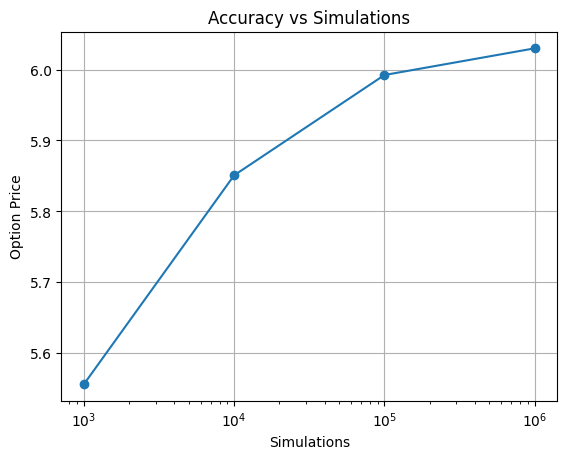

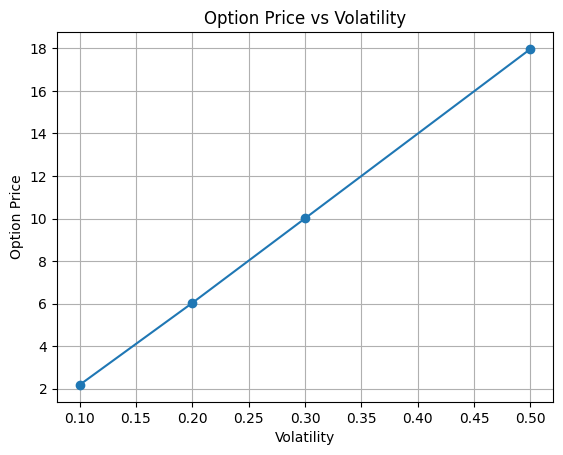

In [ ]:
import torch
import time
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Inputs
S = 100.0
K = 110.0
T = 1.0
r = 0.05
sigma = 0.2
num_simulations = 1000000

# Convert
S_tensor = torch.tensor(S, device=device)
K_tensor = torch.tensor(K, device=device)
T_tensor = torch.tensor(T, device=device)

# -----------------------------
# Main Simulation
# -----------------------------
start = time.time()

Z = torch.randn(num_simulations, device=device)

ST = S_tensor * torch.exp((r - 0.5 * sigma**2) * T + sigma * torch.sqrt(T_tensor) * Z)

payoff = torch.maximum(ST - K_tensor, torch.tensor(0.0, device=device))

option_price = torch.exp(torch.tensor(-r * T)) * torch.mean(payoff)

end = time.time()

print("\nEstimated Option Price:", round(option_price.item(), 4))
print("Execution Time:", round(end - start, 4), "seconds")

# -----------------------------
# CPU vs GPU
# -----------------------------
def run_sim(device_name):
    d = torch.device(device_name)
    S_t = torch.tensor(S, device=d)
    K_t = torch.tensor(K, device=d)
    T_t = torch.tensor(T, device=d)

    start = time.time()
    Z = torch.randn(num_simulations, device=d)
    ST = S_t * torch.exp((r - 0.5 * sigma**2) * T + sigma * torch.sqrt(T_t) * Z)
    payoff = torch.maximum(ST - K_t, torch.tensor(0.0, device=d))
    price = torch.exp(torch.tensor(-r * T)) * torch.mean(payoff)
    end = time.time()

    return price.item(), end - start

cpu_price, cpu_time = run_sim("cpu")
print("\nCPU Time:", round(cpu_time, 4), "sec")

if torch.cuda.is_available():
    gpu_price, gpu_time = run_sim("cuda")
    print("GPU Time:", round(gpu_time, 4), "sec")

# -----------------------------
# Probability of Profit
# -----------------------------
prob_profit = torch.mean((ST > K_tensor).float())
print("\nProbability of Profit:", round(prob_profit.item()*100, 2), "%")

# -----------------------------
# In/Out of Money
# -----------------------------
itm = torch.sum(ST > K_tensor).item()
otm = torch.sum(ST <= K_tensor).item()

print("In-the-money:", itm)
print("Out-of-the-money:", otm)

# -----------------------------
# Accuracy vs Simulations
# -----------------------------
sizes = [1000, 10000, 100000, 1000000]
prices = []

for s in sizes:
    Z = torch.randn(s, device=device)
    ST = S_tensor * torch.exp((r - 0.5 * sigma**2) * T + sigma * torch.sqrt(T_tensor) * Z)
    payoff = torch.maximum(ST - K_tensor, torch.tensor(0.0, device=device))
    price = torch.exp(torch.tensor(-r * T)) * torch.mean(payoff)
    prices.append(price.item())

plt.plot(sizes, prices, marker='o')
plt.xscale('log')
plt.xlabel("Simulations")
plt.ylabel("Option Price")
plt.title("Accuracy vs Simulations")
plt.grid()
plt.show()

# -----------------------------
# Volatility Effect
# -----------------------------
sigmas = [0.1, 0.2, 0.3, 0.5]
vol_prices = []

for s in sigmas:
    Z = torch.randn(num_simulations, device=device)
    ST = S_tensor * torch.exp((r - 0.5 * s**2) * T + s * torch.sqrt(T_tensor) * Z)
    payoff = torch.maximum(ST - K_tensor, torch.tensor(0.0, device=device))
    price = torch.exp(torch.tensor(-r * T)) * torch.mean(payoff)
    vol_prices.append(price.item())

plt.plot(sigmas, vol_prices, marker='o')
plt.xlabel("Volatility")
plt.ylabel("Option Price")
plt.title("Option Price vs Volatility")
plt.grid()
plt.show()

> As volatility increases, the option value increases because there is a higher chance of large profits.



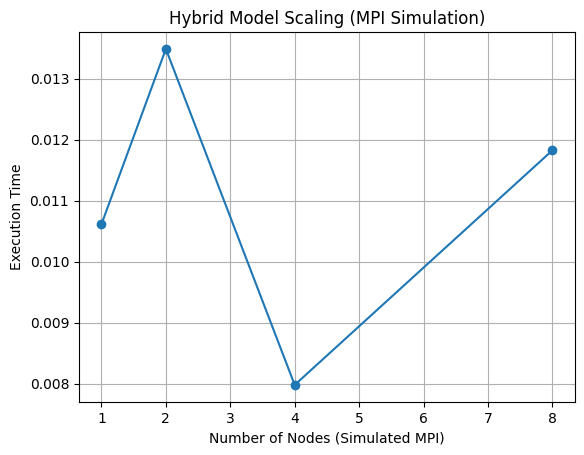

In [ ]:
import torch
import time
import matplotlib.pyplot as plt

# Inputs
S = 100.0
K = 110.0
T = 1.0
r = 0.05
sigma = 0.2
total_simulations = 1000000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

nodes = [1, 2, 4, 8]  # simulate MPI nodes
times = []

for n in nodes:
    sims_per_node = total_simulations // n

    start = time.time()

    for _ in range(n):  # simulate MPI nodes
        Z = torch.randn(sims_per_node, device=device)
        ST = S * torch.exp((r - 0.5 * sigma**2) * T + sigma * torch.sqrt(torch.tensor(T)) * Z)
        payoff = torch.maximum(ST - K, torch.tensor(0.0, device=device))

    end = time.time()

    times.append(end - start)

# Plot
plt.plot(nodes, times, marker='o')
plt.xlabel("Number of Nodes (Simulated MPI)")
plt.ylabel("Execution Time")
plt.title("Hybrid Model Scaling (MPI Simulation)")
plt.grid()
plt.show()

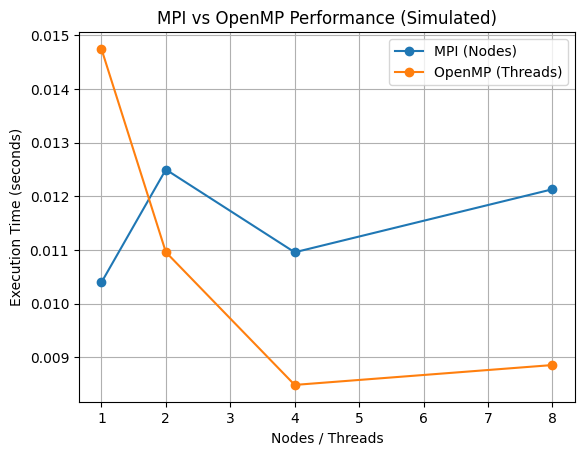

In [ ]:
import torch
import time
import matplotlib.pyplot as plt

# Inputs
S = 100.0
K = 110.0
T = 1.0
r = 0.05
sigma = 0.2
total_simulations = 1000000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# MPI Simulation (chunk-based)
# -----------------------------
mpi_nodes = [1, 2, 4, 8]
mpi_times = []

for n in mpi_nodes:
    sims_per_node = total_simulations // n

    start = time.time()

    for _ in range(n):  # simulate nodes
        Z = torch.randn(sims_per_node, device=device)
        ST = S * torch.exp((r - 0.5 * sigma**2) * T + sigma * torch.sqrt(torch.tensor(T)) * Z)
        payoff = torch.maximum(ST - K, torch.tensor(0.0, device=device))

    end = time.time()

    mpi_times.append(end - start)

# -----------------------------
# OpenMP Simulation (thread-like)
# -----------------------------
omp_threads = [1, 2, 4, 8]
omp_times = []

for t in omp_threads:
    start = time.time()

    # simulate threads by splitting work inside loop
    Z = torch.randn(total_simulations, device=device)

    # pretend splitting work across threads
    chunks = torch.chunk(Z, t)

    for chunk in chunks:
        ST = S * torch.exp((r - 0.5 * sigma**2) * T + sigma * torch.sqrt(torch.tensor(T)) * chunk)
        payoff = torch.maximum(ST - K, torch.tensor(0.0, device=device))

    end = time.time()

    omp_times.append(end - start)

# -----------------------------
# Plot Comparison
# -----------------------------
plt.plot(mpi_nodes, mpi_times, marker='o', label="MPI (Nodes)")
plt.plot(omp_threads, omp_times, marker='o', label="OpenMP (Threads)")

plt.xlabel("Nodes / Threads")
plt.ylabel("Execution Time (seconds)")
plt.title("MPI vs OpenMP Performance (Simulated)")
plt.legend()
plt.grid()
plt.show()